In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import itertools, tqdm


In [29]:

# Directorio base (cámbialo por el tuyo)
base_dir = Path('normalfriedmanpast')

#past_sizes = [500]
past_sizes = [10,50,100,200]
batch_sizes = [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 200]
num_batches_feds = [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 200]

#stream_periods = [10,100,200,500,1000]
n_instances = [10000]
stream_periods = [0.5,1,1.5,2.5]


records = []
for  past_size,stream_period, batch_size, num_batches_fed, n_instance in list(itertools.product( past_sizes, stream_periods, batch_sizes, num_batches_feds, n_instances )):
    dir_path = base_dir / f'past{past_size}' / f'stream{stream_period}' / f'instance{n_instance}' /  f'batch{batch_size}' / f'numfed{num_batches_fed}'
    results_file = dir_path / 'results.csv'
    exec_file    = dir_path / 'executiontime.txt'
    if results_file.exists() and exec_file.exists():
            # Leer solo la última fila
        df = pd.read_csv(
            results_file,
            names=['instances', 'metric'],
        )
        last_row = df.iloc[[-1]].copy()  # DataFrame con la última fila
        # Leer tiempo de ejecución (ms)
        exec_time_ms = float(exec_file.read_text().strip())
        # Anotar columnas de configuración
        last_row['stream_period'] = stream_period
        last_row['instances'] = n_instance
        last_row['batch'] = batch_size
        last_row['numfed'] = num_batches_fed
        last_row['past_history'] = past_size
        last_row['equivalent_windows'] = batch_size * num_batches_fed

        last_row['execution_time_s'] = exec_time_ms /1000
        last_row['instance_per_ms'] = n_instance/ exec_time_ms
        # Columna combinada past_stream
        last_row['experiment']       = f"p{past_size}-s{stream_period}-b{batch_size}-nf{num_batches_fed}-instances{n_instance}"
        records.append(last_row)
display(len(records))

2304

In [30]:
# Concatenar todo en un DataFrame
df_all = pd.concat(records, ignore_index=True)
df_100000 = df_all[df_all['instances'] == 100000] \
               .sort_values(by='metric', ascending=True) \
               .head(30)
df_10000 = df_all[df_all['instances'] == 10000] \
               .sort_values(by='metric', ascending=True) \

df_50000 = df_all[df_all['instances'] == 50000] \
               .sort_values(by='metric', ascending=True) \
               .head(30)
df_vanilla = df_all.sort_values(by='metric', ascending=True)
best_time=df_all.sort_values(by='execution_time_s', ascending=True).head(1)
best_metric=df_all.sort_values(by='metric', ascending=True).head(1)
df_all_time = df_all.sort_values(by='execution_time_s', ascending=True).head(50)

df_all = df_all.sort_values(by='metric', ascending=True).head(50)

# Mostrar el DataFrame completo
display(df_10000.shape)


(2304, 10)

In [54]:
best_time


,instances,metric,stream_period,batch,numfed,past_history,equivalent_windows,execution_time_s,instance_per_ms,experiment
0,10000,3.90094362500365,0.5,50,50,10,2500,6.549906,1.52674,p10-s0.5-i10000-b50-nf50-instance10000


In [55]:
best_metric

,instances,metric,stream_period,batch,numfed,past_history,equivalent_windows,execution_time_s,instance_per_ms,experiment
46,10000,3.8882485641842424,1.5,100,200,10,20000,17.509826,0.571108,p10-s1.5-i10000-b100-nf200-instance10000


In [21]:
to_match = [10, 20, 50, 100, 200]
# Opción 1: creando una máscara con isin sobre el producto
mask = (df_10000['batch'] * df_10000['numfed']).isin(to_match)
df_filtrado = df_10000[mask]
best_time=df_filtrado.sort_values(by='execution_time_s', ascending=True).head(1)
display(df_filtrado.shape)


(592, 10)

In [17]:
dest_dir = Path('/home/quique/tesis/datos')

output_path = dest_dir / 'allad.csv'
df_filtrado.to_csv(output_path, index=False)

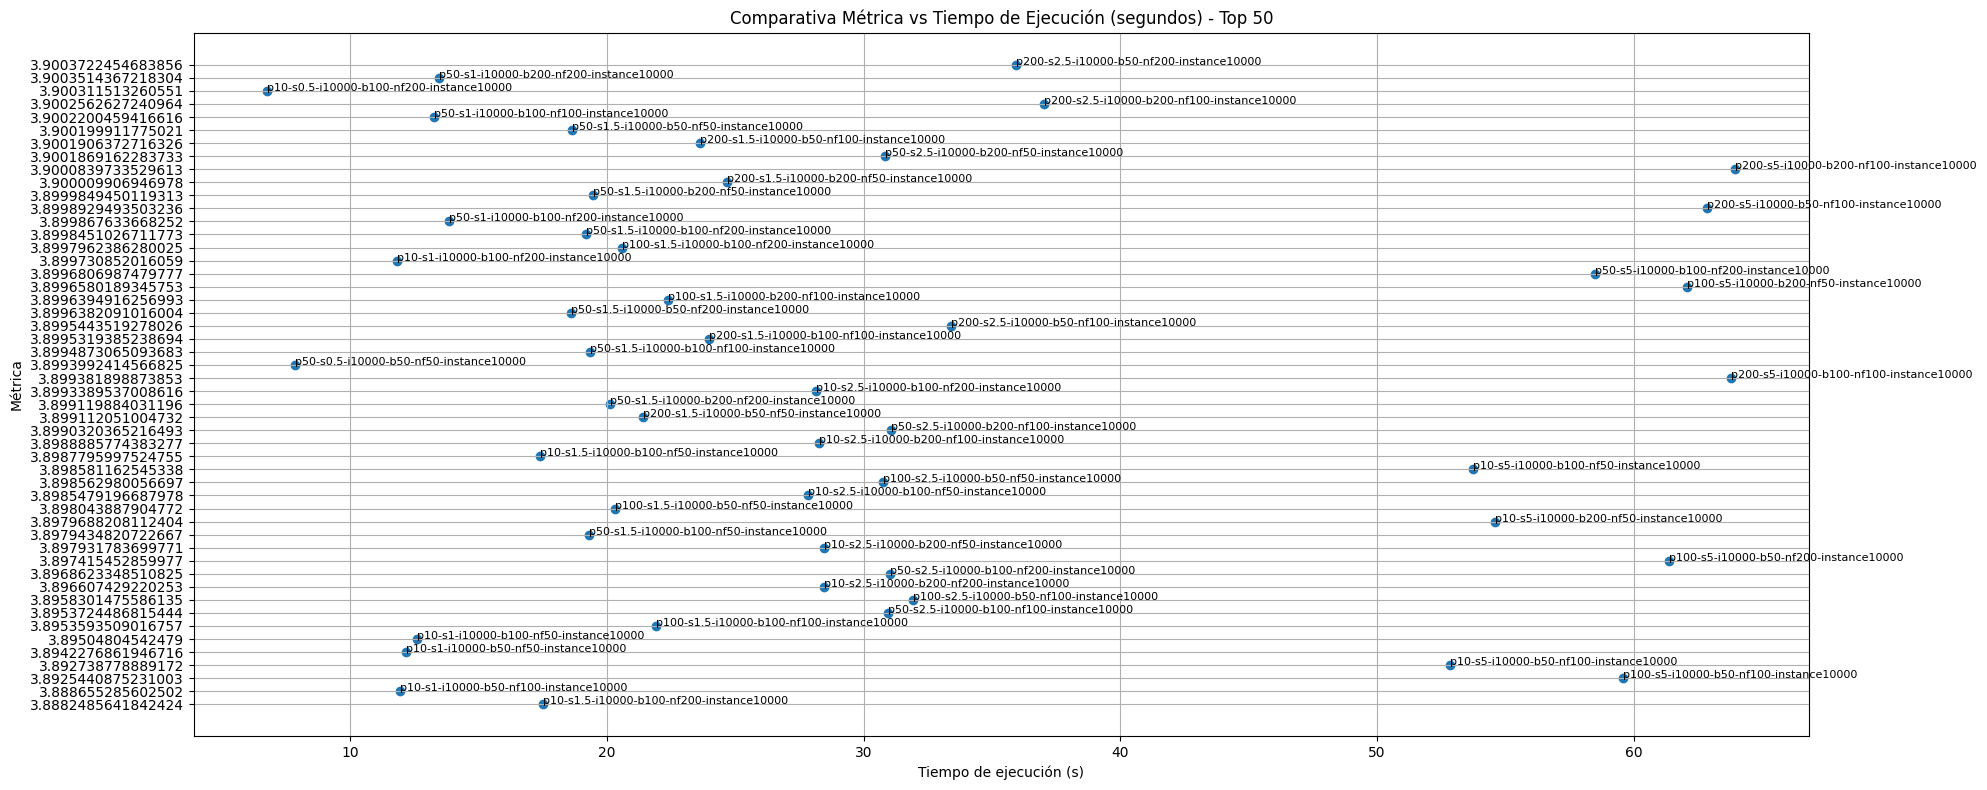

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# Ajustar este nombre si es distinto
metric_col = 'metric'

# Calcular mejores configuraciones

# Gráfico comparativo métrica vs tiempo en segundos
plt.figure(figsize=(20, 8))
plt.scatter(df_all['execution_time_s'], df_all[metric_col])

for _, row in df_all.iterrows():
    plt.text(
        row['execution_time_s'],
        row[metric_col] ,
        row['experiment'],
        fontsize=8
    )

# Destacar la mejor métrica y el mejor tiempo

plt.xlabel('Tiempo de ejecución (s)')
plt.ylabel('Métrica')
plt.title('Comparativa Métrica vs Tiempo de Ejecución (segundos) - Top 50')

plt.grid(True)
plt.tight_layout()
plt.show()


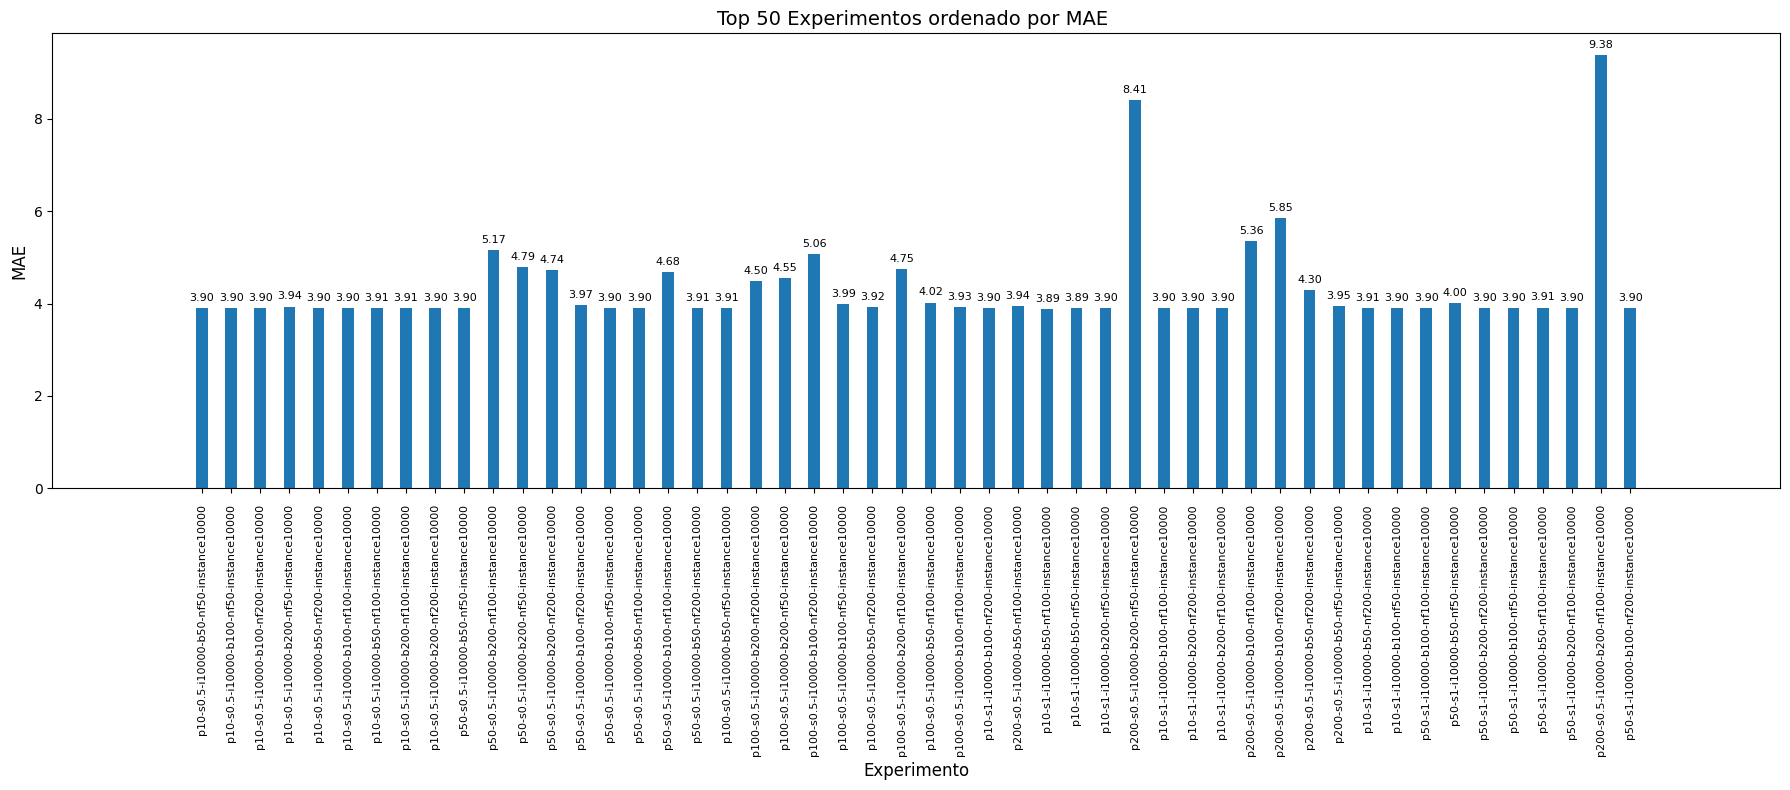

In [80]:

# 1) Nos aseguramos de que 'metric' sea numérico
df_sorted = df_all_time
df_sorted['metric'] = pd.to_numeric(df_sorted['metric'], errors='coerce')

# 2) Plot estilo “segunda gráfica”
fig, ax = plt.subplots(figsize=(18, 8))

x = range(len(df_sorted))
bar_width = 0.4
bars = ax.bar(x, df_sorted['metric'], width=bar_width)

# 3) Espaciado y ticks
ax.margins(x=0.1)
ax.tick_params(axis='x', labelsize=8, pad=8)

# Etiquetas experiment en eje X, rotadas 90°
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['experiment'], rotation=90, ha='center')

# 4) Anotar cada barra con su valor
y_offset = (df_sorted['metric'].max() - df_sorted['metric'].min()) * 0.02
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + y_offset,
        f'{h:.2f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# 5) Etiquetas y título
ax.set_ylabel('MAE', fontsize=12)
ax.set_xlabel('Experimento', fontsize=12)
ax.set_title('Top 50 Experimentos ordenado por MAE ', fontsize=14)

plt.tight_layout()
plt.show()

In [75]:
from sklearn.ensemble import RandomForestRegressor

    # Asumiendo que 'df' ya contiene las columnas:
    # window, past_size, n_instance, last_metric


    # 1. Define X e y
X = df_vanilla[['equivalent_windows', 'instances','stream_period','past_history','batch','numfed']]
y = df_vanilla['metric']


    # 2. Entrena un Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

    # 3. Extrae e imprime importancias
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

instances             0.258933
past_history          0.238747
batch                 0.182635
equivalent_windows    0.113106
stream_period         0.104780
numfed                0.101798
dtype: float64


In [9]:
df_vanilla.columns

Index(['instances', 'metric', 'stream_period', 'batch', 'numfed',
       'past_history', 'equivalent_windows', 'execution_time_s',
       'instance_per_ms', 'experiment'],
      dtype='object')

In [76]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X, y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importances = pd.Series(result.importances_mean, index=X.columns)
print(perm_importances.sort_values(ascending=False))

stream_period         1.136845
past_history          1.081381
instances             0.688101
batch                 0.475532
equivalent_windows    0.169440
numfed                0.074660
dtype: float64


In [77]:
best_time=df_all.head(1)
best_metric=df_all.sort_values(by='metric', ascending=True).head(1)